In [2]:
import os
import torch
from helper_functions import *
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

## Checking Device availability

In [3]:
# Checking Device/confirming it works with CUDA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x = torch.randn(10000, 10000, device=device)
print("Computation successful on", device)

Using device: cuda
Computation successful on cuda


## Configuration 

In [36]:
# adjust as needed to main path where data is. Should be 'DS6050_Ai_Detection' folder
data_root = Path(r"C:/Users/Jimmy/OneDrive/Desktop/test/DS6050_Ai_Detection")

# train/validate on percent of data. 0.1 = 10%, 1.0 = 100%
train_percent = 0.2

# adjust as needed for training device
batch_size = 16

# workers seem to be bugged, 0 works best
num_workers = 0

learning_rate = 1e-4

# using jpeg compression augmentation during training?
jpeg_compression = True

# number of epochs per window training step, default is 1 for AI-GenBench dataset
num_epochs_per_step = 1

# Pick any 4 models: resnet50, vit, resnet50_fft, vit_fft
# model_name = 'resnet50' 
# model_name = 'vit'
# model_name = 'resnet50_fft'
model_name = 'vit_fft'   

# additional name to add at end of model name for logging and pth file
save_model_name = "test_no_jpeg"

# fft helper for dataloading
if 'fft' in model_name:
    fft = True
else:
    fft = False

## Loading Data

In [ ]:
train_loader, val_loader, train_dataset, val_dataset, csv_name = main_data_loading(data_root, model_name, train_percent, 
                                                                                   batch_size, num_workers=num_workers, 
                                                                                   jpeg_compression=jpeg_compression)

Using model type: vit
Using FFT: True
Original class mapping: {'fake': 0, 'real': 1}
Using 20.0% of the data
Training on 23040 images, validating on 5668 images.
Saved dataset split CSV to: logs/dataset_split_20251206_145430.csv
Total records: 28708


## Confirming Window Splits

In [38]:
train_real_indices, train_fake_indices_by_w, val_real_indices, val_fake_indices_by_w, max_w = confirm_windows(train_dataset, val_dataset)

Max window index detected: 8, should be 8
Train real: 11571
Train fake w0: 1280
Train fake w1: 1318
Train fake w2: 1302
Train fake w3: 1288
Train fake w4: 1198
Train fake w5: 1235
Train fake w6: 1323
Train fake w7: 1253
Train fake w8: 1272
Val real: 2847
Val fake w0: 313
Val fake w1: 314
Val fake w2: 321
Val fake w3: 315
Val fake w4: 315
Val fake w5: 317
Val fake w6: 286
Val fake w7: 316
Val fake w8: 324


## Confirm Correct Labels for training

In [39]:
confirm_labels(train_dataset, val_dataset)

Confirm correct labels
fake -> 1
real -> 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\000000370285.jpg --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\136494.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\0040775.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\0095769.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\000000218701.jpg --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\real\000000455085.jpg --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\fake\023553.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\fake\034299.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\real\0029774.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\fake\025994.png --> 

## Make the desired model

In [40]:
model, criterion, optimizer = make_model(model_name=model_name, learning_rate=learning_rate, device=device)

## Showing JPEG transform

This will show the JPEG transform. Feel free to change the 'index' number to see different images. Will randomly pick a compression amount within the given 'jpeg_q_range'

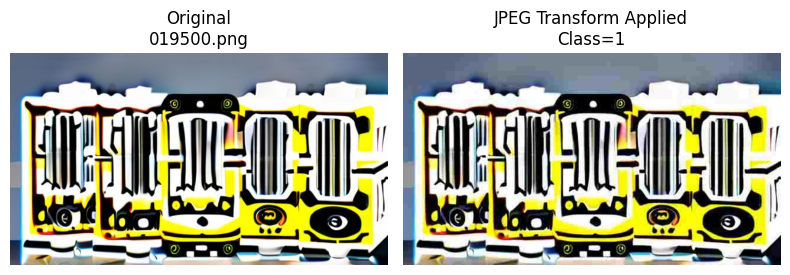

In [41]:
show_jpeg_transform_effect(val_dataset, index = 10, jpeg_q_range=(5, 60)) # range can go from 5 - 95

## Create Grid of Validating Images

Will create grid of n images (n = grid_size * grid_size). In order to load images correctly, needs to know if fft is being run, and what device is being used

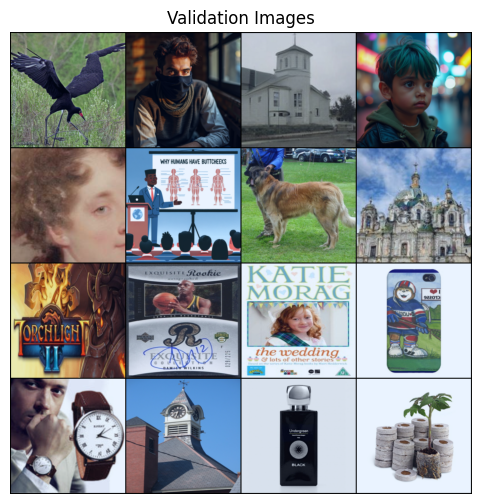

Fake: 034117.png
Fake: 021485.png
Fake: 012680.png
Fake: 026343.png
Fake: 016686.png
Fake: 028142.png
Fake: 017229.png
Fake: 032986.png
Real: 0001634.png
Real: 0005590.png
Real: 0004996.png
Real: 0000227.png
Real: 0018750.png
Real: 000000111179.jpg
Real: 0029075.png
Real: 0000258.png


In [42]:
create_grid_of_val_images(val_dataset, grid_size=4, fft=fft, device=device)

## Main training loop

Will save the model with the best f1 overall score

In [43]:
history = sliding_window_training(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    train_real_indices=train_real_indices,
    train_fake_indices_by_w=train_fake_indices_by_w,
    val_real_indices=val_real_indices,
    val_fake_indices_by_w=val_fake_indices_by_w,
    max_w=max_w,
    num_epochs_per_step=num_epochs_per_step,
    batch_size=batch_size,
    device=device,
    model_name=model_name,
    num_workers=num_workers,
    csv_name_used=csv_name,
    model_save_name=save_model_name #not a needed parameter, but will add something at end of model name logger and pth to make it unique if wanted
)

Using device: cuda (NVIDIA GeForce RTX 4070 Ti)

 - Sliding step 0: train on w[0..0], validate on w1
Train: 12851 samples (Real + Fake windows [0])
Val past: 3160 samples (windows [0])
Val next: 3161 samples (window 1)
Val all: 5668 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 0] Epoch 1/1


Training:   5%|▍         | 39/804 [00:09<03:01,  4.21batch/s, Loss=0.0189, Train Acc=89.90%]


KeyboardInterrupt: 